<a href="https://colab.research.google.com/github/IrumShehryar/ML-NLP-Coursework/blob/main/nlp/04-neural-network/neural-word-embeddings/Project01_Glove_Implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
from numpy.linalg import norm
from collections import defaultdict

# defaultdict is a subclass of the built-in dict class and provides a default value for the key that does not exist.
# This means that if a key is not found in the dictionary, instead of a KeyError being thrown, a new key is created with the default value.

# Generate Data

In [ ]:
sentences = ['I purchased a bus',
             'I drive a bus',
             'I drove a bus',
             'I drove a truck',
             'He drove a truck',
            'He purchased a bus',
             'She drove a bus',
             'She drove a car',
             'He drives a car',
             'They drive a car',
             'They drive a bus',
             'They drive a truck']

# Initialize Vocab and co-occurrence Dictionary

In [ ]:
vocab = set()
co_occurrence = defaultdict(float)
# When float is passed as the input, then a defaultdict is created with default value as zero.

# Fill in the vocab and co-ocurrence dictionary

In [ ]:
neighbor = 1
# Iterate through the corpus to build vocabulary and co-occurrence dictionary
for sentence in sentences:
    words = sentence.split()
    for i in range(len(words)):
        word = words[i]
        vocab.add(word)
        for j in range(max(0, i - neighbor), min(i + neighbor + 1, len(words))):
            if i != j:
                co_occurrence[(word, words[j])] += 1.0

In [ ]:
co_occurrence

In [ ]:
vocab

# Randomly Initialize word embeddings

In [ ]:
embeddingdim = 5
wordembeddings = {
    word: np.random.rand(embeddingdim) for word in vocab
}

In [13]:
wordembeddings

{'They': array([0.39648223, 0.62019376, 0.49757578, 0.46384583, 0.15800293]),
 'I': array([ 0.18473466,  0.18394725,  0.52685271,  0.31725255, -0.63156644]),
 'purchased': array([ 0.32048693, -0.23708105,  0.12975405,  0.56949267,  0.41648436]),
 'drive': array([0.62990239, 0.76033867, 0.42749268, 0.08304042, 0.80022274]),
 'truck': array([0.22169431, 0.6208674 , 0.52248669, 0.2626115 , 0.74371292]),
 'car': array([ 0.74353133,  0.5242172 , -0.17605023,  0.57346741,  0.14694912]),
 'a': array([0.97053412, 0.35889368, 0.77790685, 0.52841283, 0.15510253]),
 'She': array([0.62691979, 0.24596072, 0.02705335, 0.25692645, 0.62408488]),
 'drives': array([-0.3365559 ,  0.5880287 ,  0.0068989 ,  0.00895816,  0.68211825]),
 'He': array([ 0.03510292,  0.17414667, -0.22247777,  0.19628563, -0.13417205]),
 'drove': array([0.50318311, 0.56267432, 0.83512974, 0.46958748, 0.15154184]),
 'bus': array([0.78248103, 0.08146803, 0.63906906, 0.72146098, 0.80404062])}

#

# Update the word embeddings using co-ocurrence matrix and gradient descent

In [9]:
learningrate = 0.01
epochs = 1001
losses = []
for epoch in range(epochs):
    for (wordi, wordj), counts in co_occurrence.items():
        dot_product = np.dot(wordembeddings[wordi], wordembeddings[wordj]) # dot product will give the cosine similarity between two word embeddings

        # Calculate error and reduce the loss by updating wieghts

        error = dot_product - np.log(counts) # error is calculated using current similarity and and the actual value using the co-occurence matrix
        loss = 0.5 * np.power(error, 2) # Mean squared loss
        gradient = error * wordembeddings[wordj] # error is providing the difference or rate of change
        wordembeddings[wordi] -= learningrate * gradient  # We update our word embeddings using the negative gradient
                                                          # Wordembeddings = Wordembeddings - learningrate * gradient
    losses.append(np.mean(loss))
    if (epoch % 100) == 0:
        print(f"Epoch: {epoch}, Loss: {np.round(np.mean(loss))}")

Epoch: 0, Loss: 0.0
Epoch: 100, Loss: 0.0
Epoch: 200, Loss: 0.0
Epoch: 300, Loss: 0.0
Epoch: 400, Loss: 0.0
Epoch: 500, Loss: 0.0
Epoch: 600, Loss: 0.0
Epoch: 700, Loss: 0.0
Epoch: 800, Loss: 0.0
Epoch: 900, Loss: 0.0
Epoch: 1000, Loss: 0.0


# Observe the training

In [10]:
import matplotlib.pyplot as plt
from matplotlib.pyplot import style
style.use('dark_background')

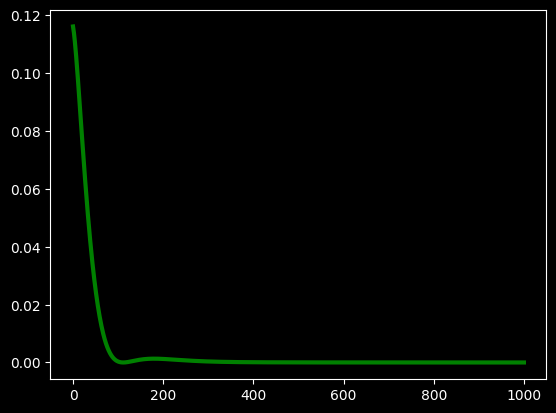

In [11]:
plt.plot(losses, 'g', lw = 3)
plt.show()

# See the values of Updated Embeddings

In [12]:
wordembeddings

{'They': array([0.39648223, 0.62019376, 0.49757578, 0.46384583, 0.15800293]),
 'I': array([ 0.18473466,  0.18394725,  0.52685271,  0.31725255, -0.63156644]),
 'purchased': array([ 0.32048693, -0.23708105,  0.12975405,  0.56949267,  0.41648436]),
 'drive': array([0.62990239, 0.76033867, 0.42749268, 0.08304042, 0.80022274]),
 'truck': array([0.22169431, 0.6208674 , 0.52248669, 0.2626115 , 0.74371292]),
 'car': array([ 0.74353133,  0.5242172 , -0.17605023,  0.57346741,  0.14694912]),
 'a': array([0.97053412, 0.35889368, 0.77790685, 0.52841283, 0.15510253]),
 'She': array([0.62691979, 0.24596072, 0.02705335, 0.25692645, 0.62408488]),
 'drives': array([-0.3365559 ,  0.5880287 ,  0.0068989 ,  0.00895816,  0.68211825]),
 'He': array([ 0.03510292,  0.17414667, -0.22247777,  0.19628563, -0.13417205]),
 'drove': array([0.50318311, 0.56267432, 0.83512974, 0.46958748, 0.15154184]),
 'bus': array([0.78248103, 0.08146803, 0.63906906, 0.72146098, 0.80404062])}

# Use embeddings to calculate the similarities

In [14]:
similarity = np.dot(wordembeddings['I'], wordembeddings['truck'])/(norm(wordembeddings['I']) * norm(wordembeddings['truck']))

In [15]:
similarity

np.float64(0.041550601580508405)

In [16]:
similarity = np.dot(wordembeddings['car'], wordembeddings['truck'])/(norm(wordembeddings['car']) * norm(wordembeddings['truck']))

In [17]:
similarity

np.float64(0.5191088210074428)

In [18]:
similarity = np.dot(wordembeddings['truck'], wordembeddings['truck'])/(norm(wordembeddings['truck']) * norm(wordembeddings['truck']))

In [19]:
similarity

np.float64(1.0000000000000002)